#### HF Losses in Ferrite Core Cross sections


In [1]:
%load_ext autoreload
%autoreload 2

import mph
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from mphsweepkit.comsol_functions import get_sweep_data, get_frequency_data, get_cascaded_dataset, print_parameters, post_processing_exprs, get_descriptions, set_parametric_sweep

Start the Comsol Server and load the model

In [2]:
# Start the COMSOL client
client = mph.start()

In [4]:
# Load the model
model = client.load('core_cross_section_initial.mph')

Access the model tree in Comsol:

In [5]:
study_name = 'Study on Cross-Sections'

# The cascaded sweeps are all accessed on the same level.
geometric_sweep = model / "studies" / study_name / "Geometry Sweep"
excitation_sweep = model / "studies" / study_name / "Excitation Sweep"
frequency_sweep = model / "studies" / study_name / "Frequency Sweep"

Get sweep parameters

In [6]:
print("Cascaded Parameter Sweep (geometry -> excitation -> frequency):")

print("\n---\nGeometric Sweep Parameters:")
geometric_sweep_data = get_sweep_data(geometric_sweep.properties())
print_parameters(geometric_sweep_data)

print("\n---\nExcitation Sweep Parameters:")
excitation_sweep_data = get_sweep_data(excitation_sweep.properties())
print_parameters(excitation_sweep_data)

print("\n---\nFrequency Sweep Parameters:")
frequency_sweep_data = get_frequency_data(frequency_sweep.properties())
print_parameters(frequency_sweep_data)

Cascaded Parameter Sweep (geometry -> excitation -> frequency):

---
Geometric Sweep Parameters:
pname: ['hor_slit', 'vert_slit', 'w', 'l_r', 'a_e']
punit: ['um', 'um', 'mm', 'mm', 'mm']
plistarr: [[0.0 0.0 0.0]
 [0.0 0.0 0.0]
 [5.0 10.0 15.0]
 [0.0 0.0 0.0]
 [5.0 10.0 15.0]]
sweeptype: sparse
plistarr_shape: (5, 3)

---
Excitation Sweep Parameters:
pname: ['b_mean']
punit: ['mT']
plistarr: [[25.0 50.0 75.0 100.0]]
sweeptype: filled
plistarr_shape: (1, 4)

---
Frequency Sweep Parameters:
frequencies: [100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0]
unit: kHz


Investigate the parameter descriptions

In [7]:
print_parameters(get_descriptions(model, ["w", "a_e", "l_r"]))

w: width
a_e: semi axis of ellipse
l_r: length of rectangle


Set sweep geometric sweep parameters to get circles with radii: 5, 10, 15 mm

In [8]:
# Define a geometric sweep of cylinders with round cross-sections of different radii
param__radii = np.array([5, 10, 15])  # Radii for the cross-section in mm

# Create arrays for the parameters based on the radii
param__hor_slit = np.zeros_like(param__radii)  # Horizontal slit dimensions
param__vert_slit = np.zeros_like(param__radii) # Vertical slit dimensions
param__w = param__radii * 2
param__l_r = np.zeros_like(param__radii)  # Length dimensions
param__a_e = param__radii

# Set the parametric sweep for the geometric sweep
set_parametric_sweep(
    sweep_obj=geometric_sweep,
    param_names=["hor_slit", "vert_slit", "w", "l_r", "a_e"],
    param_units=["um", "um", "mm", "mm", "mm"],
    param_values=np.array(
        [param__hor_slit, param__vert_slit, param__w, param__l_r, param__a_e],
        dtype=float,
    ),
    sweep_type="sparse",
)

print("Updated Geometric Sweep Parameters:")
geometric_sweep_data = get_sweep_data(geometric_sweep.properties())
print_parameters(geometric_sweep_data)

Updated Geometric Sweep Parameters:
pname: ['hor_slit', 'vert_slit', 'w', 'l_r', 'a_e']
punit: ['um', 'um', 'mm', 'mm', 'mm']
plistarr: [[0.0 0.0 0.0]
 [0.0 0.0 0.0]
 [10.0 20.0 30.0]
 [0.0 0.0 0.0]
 [5.0 10.0 15.0]]
sweeptype: sparse
plistarr_shape: (5, 3)


In [9]:
# Build the full cascaded dataset in COMSOL sweep order:
# geometry_sweep -> excitation_sweep -> frequency_sweep.
df = get_cascaded_dataset(
    geometric_sweep_data,
    excitation_sweep_data,
    frequency_sweep_data,
)

print(df)

     hor_slit  vert_slit     w  l_r   a_e  b_mean    freq
0         0.0        0.0  10.0  0.0   5.0    25.0   100.0
1         0.0        0.0  10.0  0.0   5.0    25.0   200.0
2         0.0        0.0  10.0  0.0   5.0    25.0   300.0
3         0.0        0.0  10.0  0.0   5.0    25.0   400.0
4         0.0        0.0  10.0  0.0   5.0    25.0   500.0
..        ...        ...   ...  ...   ...     ...     ...
151       0.0        0.0  30.0  0.0  15.0   100.0   900.0
152       0.0        0.0  30.0  0.0  15.0   100.0  1000.0
153       0.0        0.0  30.0  0.0  15.0   100.0  1100.0
154       0.0        0.0  30.0  0.0  15.0   100.0  1200.0
155       0.0        0.0  30.0  0.0  15.0   100.0  1300.0

[156 rows x 7 columns]


Run the simulations:

In [10]:
# Let COMSOL expand the batch sweep internally and solve the study.
try:
    model.build()
except Exception:
    pass

model.solve(study_name)
print(f"Submitted the Batch Sweep for study '{study_name}'.")

Submitted the Batch Sweep for study 'Study on Cross-Sections'.


### Evaluate Results - save relevant data/results

In [11]:
# List all available datasets
datasets = model.datasets()
print(f"Available datasets: {datasets}")

Available datasets: ['Study on Cross-Sections//Solution 1', 'Study on Cross-Sections//Parametric Solutions 1']


In [12]:
# Attach all post-processing results to the matching parameter values
for column_name, spec in post_processing_exprs.items():
    df[column_name] = model.evaluate(
        expression=spec["expression"],
        unit=spec["unit"],
        dataset=datasets[-1],
    )

print(df)

     hor_slit  vert_slit     w  l_r   a_e  b_mean    freq        p_loss  \
0         0.0        0.0  10.0  0.0   5.0    25.0   100.0  1.138793e+03   
1         0.0        0.0  10.0  0.0   5.0    25.0   200.0  3.233053e+03   
2         0.0        0.0  10.0  0.0   5.0    25.0   300.0  6.623256e+03   
3         0.0        0.0  10.0  0.0   5.0    25.0   400.0  1.190620e+04   
4         0.0        0.0  10.0  0.0   5.0    25.0   500.0  1.982238e+04   
..        ...        ...   ...  ...   ...     ...     ...           ...   
151       0.0        0.0  30.0  0.0  15.0   100.0   900.0  1.757114e+07   
152       0.0        0.0  30.0  0.0  15.0   100.0  1000.0  2.194106e+07   
153       0.0        0.0  30.0  0.0  15.0   100.0  1100.0  2.581070e+07   
154       0.0        0.0  30.0  0.0  15.0   100.0  1200.0  2.944784e+07   
155       0.0        0.0  30.0  0.0  15.0   100.0  1300.0  3.298952e+07   

            p_mag          p_el  
0    1.016235e+03  1.225583e+02  
1    2.542864e+03  6.901880e+02

Exemplary Visualization of average loss density in the cross-section

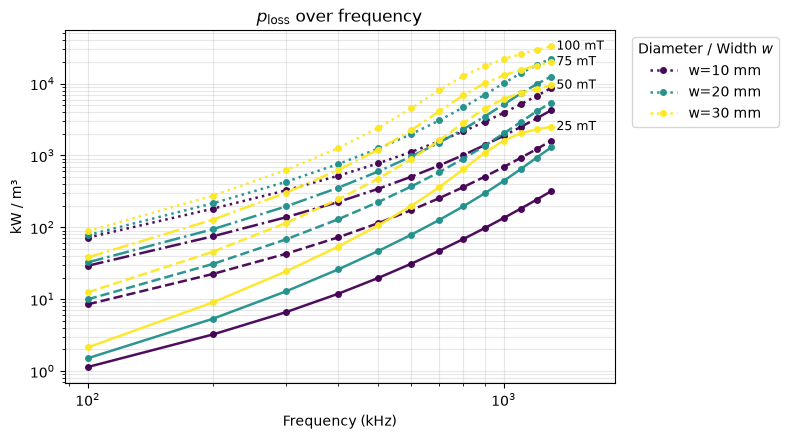

<Figure size 640x480 with 0 Axes>

In [13]:
selected_post_processing_key = "p_loss"
selected_post_processing = post_processing_exprs[selected_post_processing_key]


fig, ax = plt.subplots(figsize=(8, 4.5))

# Color map by geometry (w)
w_values = sorted(df["w"].unique())
cmap = plt.get_cmap("viridis", len(w_values))
w_to_color = {w: cmap(i) for i, w in enumerate(w_values)}

# Optional: linestyle by b_mean (helps distinguish curves with same color)
b_values = sorted(df["b_mean"].unique())
linestyles = ["-", "--", "-.", ":"]
b_to_ls = {b: linestyles[i % len(linestyles)] for i, b in enumerate(b_values)}

# Track one curve end per b_mean for labeling (choose highest frequency point)
label_points = {}

for (w_val, b_val), g in df.sort_values("freq").groupby(["w", "b_mean"], sort=True):
    x = g["freq"].to_numpy()
    y = (g[selected_post_processing_key] / 1000).to_numpy()  # kW/m³

    ax.plot(
        x, y,
        marker="o",
        ms=4,
        lw=1.8,
        alpha=0.95,
        color=w_to_color[w_val],      # same color for same w
        linestyle=b_to_ls[b_val],     # optional: style by b_mean
        label=f"w={w_val:.3g} mm"
    )

    # store rightmost point for b_mean label candidates
    i = np.argmax(x)
    xp, yp = x[i], y[i]
    # keep highest y at right edge for this b_mean to avoid overlap a bit
    if b_val not in label_points or (xp >= label_points[b_val][0] and yp > label_points[b_val][1]):
        label_points[b_val] = (xp, yp)

# Axes (datasheet-like)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(f"Frequency (kHz)")
ax.set_ylabel("kW / m³")
ax.set_title(f"{selected_post_processing['label']} over frequency")
ax.grid(True, which="both", alpha=0.3)

# Deduplicated legend for geometry (w)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(),
          title=r"Diameter / Width $w$", bbox_to_anchor=(1.02, 1), loc="upper left")

# Add b_mean text labels near curve ends (datasheet style)
for b_val, (xp, yp) in label_points.items():
    txt = ax.text(
        xp * 1.03, yp, f"{b_val:.3g} mT",
        fontsize=9, va="center", ha="left", color="black"
    )
    # white halo for readability
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

# Make room on right for labels
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax * 1.25)

plt.tight_layout()
plt.show()# Legend with one entry per w (deduplicate)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(
    by_label.values(),
    by_label.keys(),
    title=r"Diameter / Width $w$",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Saving Models

Save the model with or without solution data:

In [14]:
# Save to new file
model.save('core_cross_section_solved.mph')

### Release the Client

In [15]:
client.remove(model)
client.clear()
client.disconnect()